In [1]:
# Pipeline B – Classificazione (Multi-Asset)

#Obiettivo: Predire se il giorno successivo il titolo azionario salirà (1) o scenderà (0).

#Dataset: multi_assets_supervised.csv  
#Modello: Decision Tree Classifier  
#Split temporale: train (2015–2021), test (2022–oggi)

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [68]:
df_all = pd.read_csv(
    "../data/processed/multi_assets_supervised.csv",
    index_col=0,
    parse_dates=True
)

In [69]:
split_date = "2022-01-01"

train_all = df_all[df_all.index < split_date]
test_all  = df_all[df_all.index >= split_date]

In [71]:
features = [

    "Return",
    "Return_lag1",
    "Return_lag2",
    "Return_lag3",

    "Momentum_5",
    "Momentum_10",

    "MA_ratio",

    "Volatility_10",

    "RSI"

]

X_train_cls = train_all[features]
X_test_cls  = test_all[features]

y_train_cls = train_all["Target_Class"]
y_test_cls  = test_all["Target_Class"]

X_train_cls.shape, X_test_cls.shape

((8085, 9), (5005, 9))

In [72]:
clf = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

clf.fit(X_train_cls, y_train_cls)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [73]:
y_pred_cls = clf.predict(X_test_cls)

In [74]:
accuracy = accuracy_score(y_test_cls, y_pred_cls)
accuracy

0.5212787212787213

In [75]:
print(classification_report(y_test_cls, y_pred_cls))

              precision    recall  f1-score   support

           0       0.49      0.24      0.32      2383
           1       0.53      0.78      0.63      2622

    accuracy                           0.52      5005
   macro avg       0.51      0.51      0.48      5005
weighted avg       0.51      0.52      0.48      5005



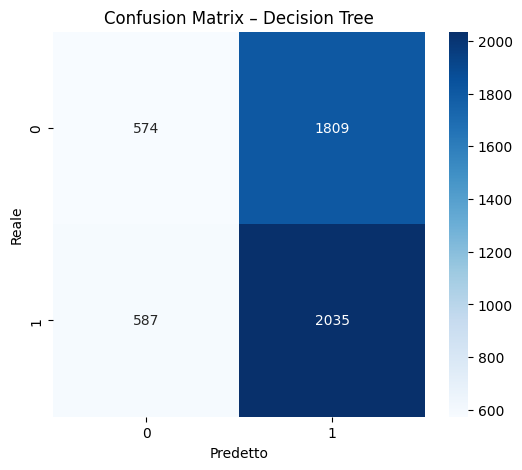

In [76]:
import seaborn as sns

cm = confusion_matrix(y_test_cls, y_pred_cls)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Confusion Matrix – Decision Tree")

plt.show()

In [77]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_cls, y_train_cls)

y_pred_nb = nb.predict(X_test_cls)

In [78]:
from sklearn.metrics import accuracy_score

accuracy_nb = accuracy_score(y_test_cls, y_pred_nb)
accuracy_nb

0.5274725274725275

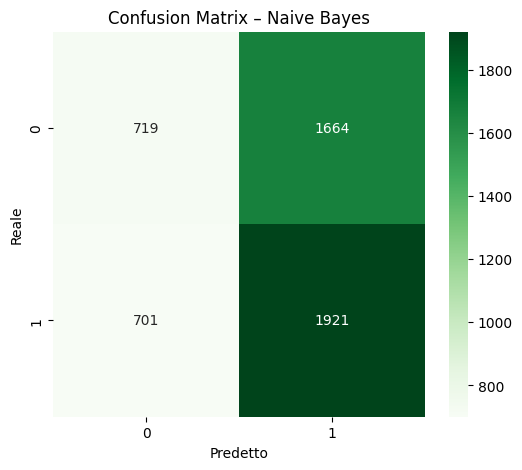

In [79]:
cm_nb = confusion_matrix(y_test_cls, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Confusion Matrix – Naive Bayes")

plt.show()

In [80]:
from sklearn.metrics import classification_report

print(classification_report(y_test_cls, y_pred_nb))

              precision    recall  f1-score   support

           0       0.51      0.30      0.38      2383
           1       0.54      0.73      0.62      2622

    accuracy                           0.53      5005
   macro avg       0.52      0.52      0.50      5005
weighted avg       0.52      0.53      0.50      5005



In [81]:
accuracy_dt = accuracy_score(y_test_cls, y_pred_cls)

print("Accuracy Decision Tree:", accuracy_dt)
print("Accuracy Naive Bayes:", accuracy_nb)

Accuracy Decision Tree: 0.5212787212787213
Accuracy Naive Bayes: 0.5274725274725275


In [82]:
split_date = "2022-01-01"

train_all = df_all[df_all.index < split_date]
test_all  = df_all[df_all.index >= split_date]

In [83]:
features = [

    "Return",
    "Return_lag1",
    "Return_lag2",
    "Return_lag3",

    "Momentum_5",
    "Momentum_10",

    "MA_ratio",

    "Volatility_10",

    "RSI"

]

X_train_cls = train_all[features]
X_test_cls  = test_all[features]

y_train_cls = train_all["Target_Class"]
y_test_cls  = test_all["Target_Class"]

In [84]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

clf = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    random_state=42
)

clf.fit(X_train_cls, y_train_cls)

y_pred_dt = clf.predict(X_test_cls)

accuracy_dt = accuracy_score(y_test_cls, y_pred_dt)
accuracy_dt

0.5154845154845155

In [85]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_cls, y_train_cls)

y_pred_nb = nb.predict(X_test_cls)

accuracy_nb = accuracy_score(y_test_cls, y_pred_nb)
accuracy_nb

0.5274725274725275

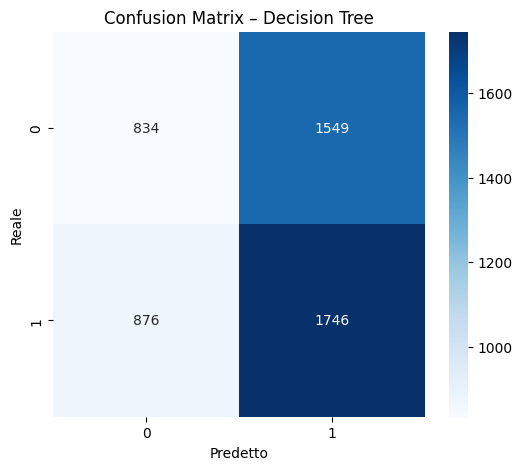

In [86]:
cm_dt = confusion_matrix(y_test_cls, y_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Confusion Matrix – Decision Tree")
plt.show()

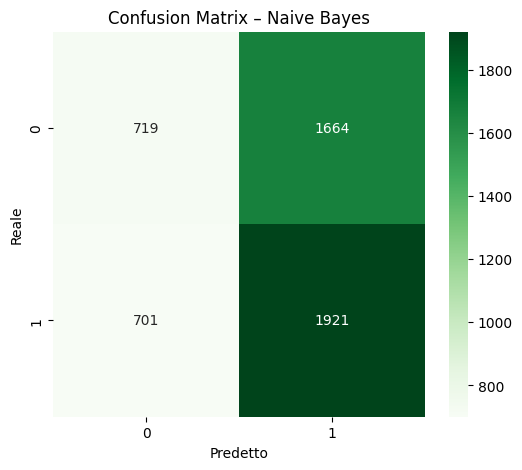

In [87]:
cm_nb = confusion_matrix(y_test_cls, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Confusion Matrix – Naive Bayes")
plt.show()

In [88]:
clf = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42
)

In [89]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(

    n_estimators=300,
    max_depth=10,
    min_samples_leaf=20,

    class_weight={0:1,1:1.2},

    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_cls, y_train_cls)

y_pred_rf = rf.predict(X_test_cls)

accuracy_rf = accuracy_score(y_test_cls, y_pred_rf)
accuracy_rf

0.5204795204795205

In [90]:
y_prob_rf = rf.predict_proba(X_test_cls)[:, 1]

In [91]:
threshold = 0.55
y_pred_custom = (y_prob_rf > threshold).astype(int)

accuracy_custom = accuracy_score(y_test_cls, y_pred_custom)
accuracy_custom

0.5182817182817183

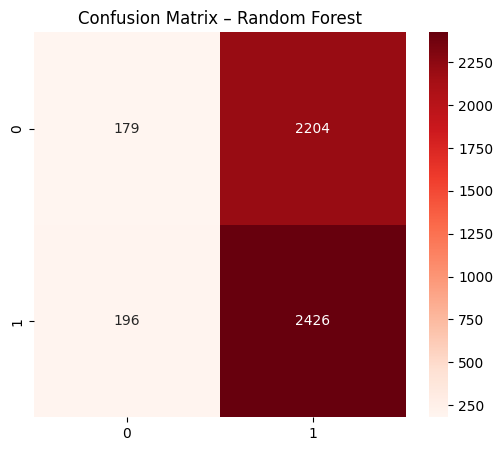

In [92]:
cm_rf = confusion_matrix(y_test_cls, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix – Random Forest")
plt.show()

In [93]:
import pandas as pd
import numpy as np

df_all = pd.read_csv(
    "../data/processed/multi_assets_threshold_002.csv",
    index_col=0,
    parse_dates=True
)

In [94]:
split_date = "2022-01-01"

train_all = df_all[df_all.index < split_date]
test_all  = df_all[df_all.index >= split_date]

In [95]:
features = [

    "Return",
    "Return_lag1",
    "Return_lag2",
    "Return_lag3",

    "Momentum_5",
    "Momentum_10",

    "MA_ratio",

    "Volatility_10",

    "RSI"

]

X_train_cls = train_all[features]
X_test_cls  = test_all[features]

y_train_cls = train_all["Target_Class"]
y_test_cls  = test_all["Target_Class"]

In [96]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_cls, y_train_cls)

y_pred_rf = rf.predict(X_test_cls)

accuracy_rf = accuracy_score(y_test_cls, y_pred_rf)
accuracy_rf

0.5255147717099373

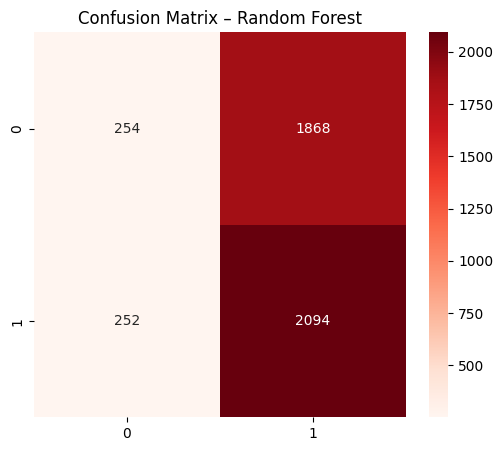

In [97]:
cm_rf = confusion_matrix(y_test_cls, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix – Random Forest")
plt.show()

In [98]:
import pandas as pd
import numpy as np

df_all = pd.read_csv(
    "../data/processed/multi_assets_threshold_001.csv",
    index_col=0,
    parse_dates=True
)

In [99]:
split_date = "2022-01-01"

train_all = df_all[df_all.index < split_date]
test_all  = df_all[df_all.index >= split_date]

In [104]:
features = [

    "Return",
    "Return_lag1",
    "Return_lag2",
    "Return_lag3",

    "Momentum_5",
    "Momentum_10",

    "MA_ratio",

    "Volatility_10",

    "RSI"

]

X_train_cls = train_all[features]
X_test_cls  = test_all[features]

y_train_cls = train_all["Target_Class"]
y_test_cls  = test_all["Target_Class"]

In [105]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_cls, y_train_cls)

y_pred_rf = rf.predict(X_test_cls)

accuracy_rf = accuracy_score(y_test_cls, y_pred_rf)
accuracy_rf

0.524988213107025

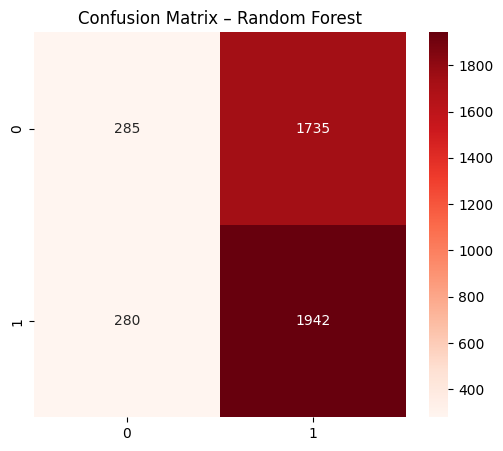

In [106]:
cm_rf = confusion_matrix(y_test_cls, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Reds")
plt.title("Confusion Matrix – Random Forest")
plt.show()

In [107]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

clf = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    random_state=42
)

clf.fit(X_train_cls, y_train_cls)

y_pred_dt = clf.predict(X_test_cls)

accuracy_dt = accuracy_score(y_test_cls, y_pred_dt)
accuracy_dt

0.5308816595945309

In [108]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_cls, y_train_cls)

y_pred_nb = nb.predict(X_test_cls)

accuracy_nb = accuracy_score(y_test_cls, y_pred_nb)
accuracy_nb

0.5273455917020273

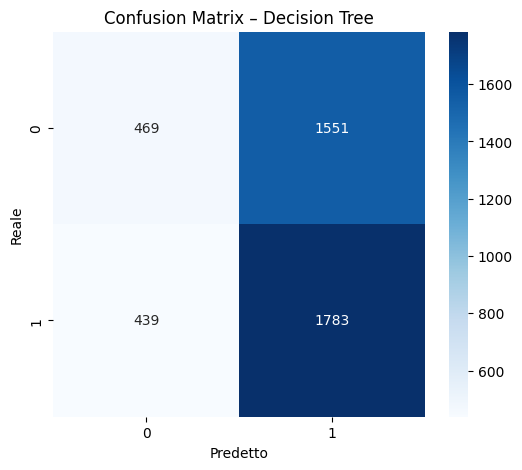

In [109]:
cm_dt = confusion_matrix(y_test_cls, y_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Confusion Matrix – Decision Tree")
plt.show()

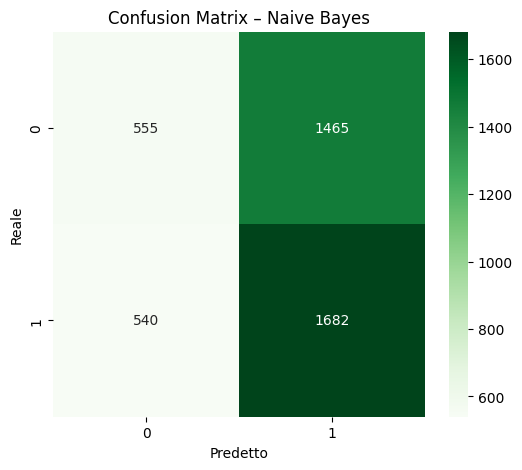

In [110]:
cm_nb = confusion_matrix(y_test_cls, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Confusion Matrix – Naive Bayes")
plt.show()